# Ứng dụng 3 - Khám phá sở thích khách hàng E-commerce từ reviews

**Quy trình:** Data -> Understand -> Clean -> Represent -> Train -> Validate -> Test -> Persist -> Deploy

## 1. Bài toán và nguồn dữ liệu

- **Dataset:** Women's E-Commerce Clothing Reviews - https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
- **Kích thước gốc:** 23.486 quan sát, 11 cột (trong đó `Unnamed: 0` chỉ là chỉ số xuất CSV).
- **Mục tiêu:** dự đoán nhóm sản phẩm khách hàng quan tâm (`Department Name`) từ nội dung nhận xét và các tín hiệu tabular không làm lộ target.
- **Một quan sát:** một đánh giá ẩn danh của khách hàng cho một sản phẩm thời trang, gồm tiêu đề, nội dung review, tuổi, rating, quyết định khuyến nghị và số lượt phản hồi tích cực.
- **Định nghĩa:** X = comment (`Title + Review Text`) + `Age`, `Rating`, `Recommended IND`, `Positive Feedback Count`; y = `Department Name`.

`Division Name` và `Class Name` không được dùng làm feature vì thuộc cùng hệ phân cấp với `Department Name` và có thể tiết lộ nhãn. `Clothing ID` chỉ dùng làm group khi chia dữ liệu, không đưa vào model.

In [1]:
from pathlib import Path
import json, os, warnings
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-asg02")
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, label_binarize
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from time import perf_counter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
ROOT = Path.cwd()
(ROOT / "models").mkdir(exist_ok=True)
(ROOT / "artifacts").mkdir(exist_ok=True)
(ROOT / "figures").mkdir(exist_ok=True)
RANDOM_STATE = 42

## 2. Kiểm tra dữ liệu bắt buộc

In [2]:
df_raw = pd.read_csv(ROOT / "Womens Clothing E-Commerce Reviews.csv")
print("shape:", df_raw.shape)
display(df_raw.head().T)
df_raw.info()
display(df_raw.describe(include="number").T[["count", "mean", "std", "min", "50%", "max"]].round(2))
display(df_raw.describe(exclude="number").T[["count", "unique", "top", "freq"]])
print("\nMissing values:\n", df_raw.isna().sum())
print("\nDuplicated full records:", df_raw.duplicated().sum())
print("\nTarget distribution:\n", df_raw["Department Name"].value_counts(dropna=False))

shape: (23486, 11)


,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
Clothing ID,767,1080,1077,1049,847
Age,33,34,60,50,47
Title,NaN,NaN,Some major design flaws,My favorite buy!,Flattering shirt
Review Text,Absolutely wonderful - silky and sexy and comf...,Love this dress! it's sooo pretty. i happene...,I had such high hopes for this dress and reall...,"I love, love, love this jumpsuit. it's fun, fl...",This shirt is very flattering to all due to th...
Rating,4,5,3,5,5
Recommended IND,1,1,0,1,1
Positive Feedback Count,0,4,0,0,6
Division Name,Initmates,General,General,General Petite,General
Department Name,Intimate,Dresses,Dresses,Bottoms,Tops


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


,count,mean,std,min,50%,max
Unnamed: 0,23486.0,11742.50,6779.97,0.0,11742.5,23485.0
Clothing ID,23486.0,918.12,203.30,0.0,936.0,1205.0
Age,23486.0,43.20,12.28,18.0,41.0,99.0
Rating,23486.0,4.20,1.11,1.0,5.0,5.0
Recommended IND,23486.0,0.82,0.38,0.0,1.0,1.0
Positive Feedback Count,23486.0,2.54,5.70,0.0,1.0,122.0


,count,unique,top,freq
Title,19676,13993,Love it!,136
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3
Division Name,23472,3,General,13850
Department Name,23472,6,Tops,10468
Class Name,23472,20,Dresses,6319



Missing values:
 Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Duplicated full records: 0

Target distribution:
 Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
NaN            14
Name: count, dtype: int64


## 3. Làm sạch, chia dữ liệu và chống leakage

Quy trình được thực hiện theo thứ tự: bỏ cột chỉ số -> loại target/comment thiếu -> chuẩn hóa khoảng trắng -> loại comment trùng -> chia group-aware -> fit biểu diễn trên train. Hai lần `StratifiedGroupKFold` tạo tỷ lệ xấp xỉ 70/15/15, duy trì phân bố lớp và không để cùng `Clothing ID` xuất hiện ở nhiều tập.

Đây là kiểm soát leakage quan trọng vì nhiều review có thể cùng nói về một sản phẩm. Mọi vectorizer, scaler và estimator phía sau đều nằm trong `Pipeline` và chỉ được fit từ train khi so sánh model.

In [3]:
target = "Department Name"
numeric_features = ["Age", "Rating", "Recommended IND", "Positive Feedback Count"]
text_feature = "Review Combined"
features = [text_feature, *numeric_features]

df = df_raw.drop(columns=["Unnamed: 0"], errors="ignore").copy()
df = df.dropna(subset=[target, "Review Text"]).copy()
df["Title"] = df["Title"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df["Review Text"] = df["Review Text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df[text_feature] = (df["Title"] + " " + df["Review Text"]).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["Review Text"].str.split().str.len() >= 2].copy()
df["_normalized_comment"] = df[text_feature].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
before = len(df)
df = df.drop_duplicates(subset=["_normalized_comment"], keep="first").reset_index(drop=True)
print(f"Removed {before-len(df):,} duplicated comments; cleaned shape = {df.shape}")
print(df[target].value_counts())

X, y = df[features], df[target].astype(str)
groups = df["Clothing ID"].astype(str)

outer = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(outer.split(X, y, groups))
X_trainval_raw, y_trainval_raw = X.iloc[trainval_idx], y.iloc[trainval_idx]
groups_trainval = groups.iloc[trainval_idx]

inner = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=RANDOM_STATE + 1)
train_local, val_local = next(inner.split(X_trainval_raw, y_trainval_raw, groups_trainval))
train_idx = trainval_idx[train_local]
val_idx = trainval_idx[val_local]

X_train = X.iloc[train_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
X_val = X.iloc[val_idx].reset_index(drop=True)
y_val = y.iloc[val_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
g_train, g_val, g_test = groups.iloc[train_idx], groups.iloc[val_idx], groups.iloc[test_idx]

print("train/validation/test:", X_train.shape, X_val.shape, X_test.shape)
print("ratios:", np.round(np.array([len(X_train), len(X_val), len(X_test)]) / len(X), 4))
print("group overlap train-val:", len(set(g_train) & set(g_val)))
print("group overlap train-test:", len(set(g_train) & set(g_test)))
print("group overlap val-test:", len(set(g_val) & set(g_test)))
display(pd.concat({
    "train": y_train.value_counts(normalize=True),
    "validation": y_val.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}, axis=1).fillna(0).round(4))

Removed 5 duplicated comments; cleaned shape = (22623, 12)
Department Name
Tops        10047
Dresses      6145
Bottoms      3661
Intimate     1650
Jackets      1002
Trend         118
Name: count, dtype: int64
train/validation/test: (16077, 5) (3211, 5) (3335, 5)
ratios: [0.7106 0.1419 0.1474]
group overlap train-val: 0
group overlap train-test: 0
group overlap val-test: 0


,train,validation,test
Department Name,,,
Tops,0.4464,0.4469,0.4303
Dresses,0.2673,0.2678,0.2960
Bottoms,0.1627,0.1629,0.1568
Intimate,0.0733,0.0735,0.0705
Jackets,0.0450,0.0436,0.0417
Trend,0.0053,0.0053,0.0048


## 4. EDA: hành vi, nhóm quan tâm và đặc trưng comment

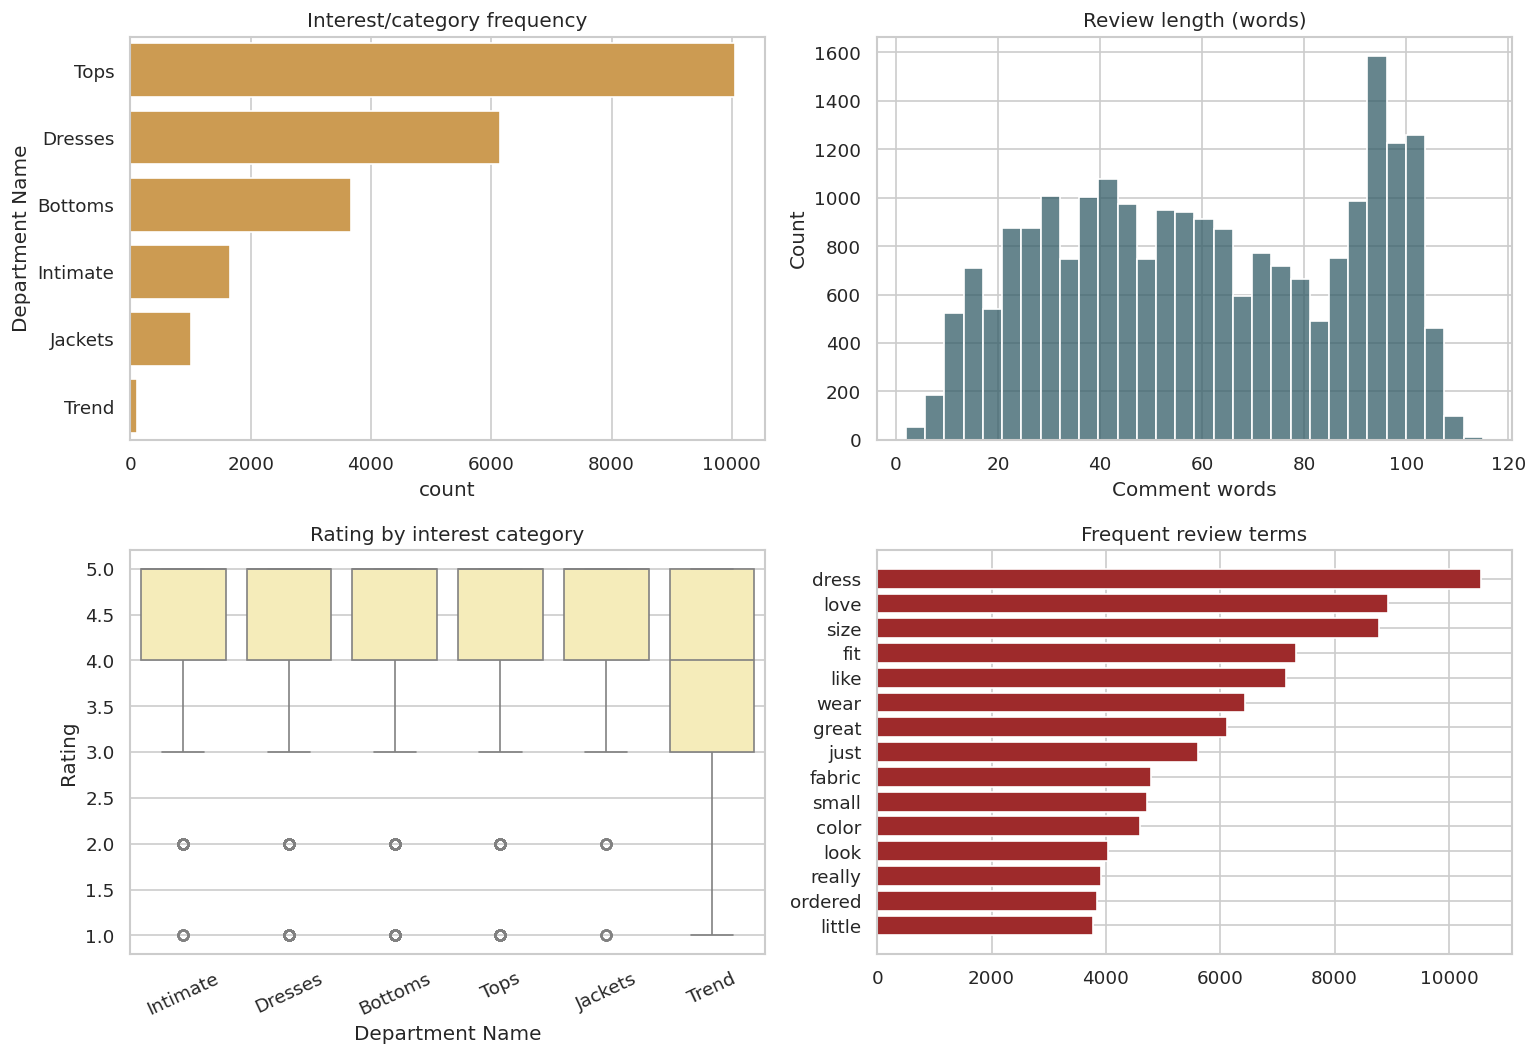

Observation: Tops và Dresses chiếm đa số; Trend là lớp hiếm. Comment chủ yếu có độ dài trung bình.
Interpretation: review chứa từ mô tả kiểu dáng, độ vừa vặn và loại trang phục; rating giữa các department khá gần nhau.
ML implication: macro-F1 cần được ưu tiên để không che khuất lớp hiếm; text dự kiến đóng góp nhiều hơn các biến tabular.


In [4]:
eda = df.copy()
eda["Comment words"] = eda["Review Text"].str.split().str.len()
term_vectorizer = CountVectorizer(stop_words="english", max_features=15)
term_matrix = term_vectorizer.fit_transform(eda["Review Text"])
term_counts = np.asarray(term_matrix.sum(axis=0)).ravel()
terms = pd.DataFrame({"term": term_vectorizer.get_feature_names_out(), "count": term_counts}).sort_values("count")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.countplot(data=eda, y=target, order=eda[target].value_counts().index, ax=axes[0, 0], color="#E09F3E")
axes[0, 0].set_title("Interest/category frequency")
sns.histplot(data=eda, x="Comment words", bins=30, ax=axes[0, 1], color="#335C67")
axes[0, 1].set_title("Review length (words)")
sns.boxplot(data=eda, x=target, y="Rating", ax=axes[1, 0], color="#FFF3B0")
axes[1, 0].tick_params(axis="x", rotation=25)
axes[1, 0].set_title("Rating by interest category")
axes[1, 1].barh(terms["term"], terms["count"], color="#9E2A2B")
axes[1, 1].set_title("Frequent review terms")
plt.tight_layout()
plt.savefig(ROOT / "figures/ecommerce_eda.png", dpi=160, bbox_inches="tight")
plt.show()

print("Observation: Tops và Dresses chiếm đa số; Trend là lớp hiếm. Comment chủ yếu có độ dài trung bình.")
print("Interpretation: review chứa từ mô tả kiểu dáng, độ vừa vặn và loại trang phục; rating giữa các department khá gần nhau.")
print("ML implication: macro-F1 cần được ưu tiên để không che khuất lớp hiếm; text dự kiến đóng góp nhiều hơn các biến tabular.")

## 5. Biểu diễn: tabular, TF-IDF và token embeddings

Nhánh model dùng TF-IDF unigram/bigram ghép với 4 feature tabular đã impute và MaxAbs-scale. Kết quả là ma trận sparse X thuộc R^(B x D).

Để thể hiện đầy đủ chuỗi của Lecture 02, notebook còn tạo vocabulary chỉ từ train, ánh xạ token thành ID rồi học embedding từ ma trận term-document bằng Truncated SVD. Với batch minh họa: token IDs có dạng B x T và token embeddings có dạng B x T x d.

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MaxAbsScaler()),
])
tabular_preprocessor = ColumnTransformer([
    ("num", clone(numeric_pipeline), numeric_features),
])
combined_preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(
        lowercase=True, strip_accents="unicode", stop_words="english",
        ngram_range=(1, 2), min_df=3, max_df=0.98, max_features=8000,
        sublinear_tf=True, dtype=np.float64,
    ), text_feature),
    ("num", clone(numeric_pipeline), numeric_features),
], sparse_threshold=0.3)

preview_transformer = clone(combined_preprocessor)
representation = preview_transformer.fit_transform(X_train)
display(df[["Title", "Review Text", *numeric_features, target]].head(1).T)
print("Raw feature matrix:", X_train.shape)
print("TF-IDF + tabular model input:", representation.shape, representation.dtype)
print("Sparse matrix:", hasattr(representation, "nnz"), "non-zero values:", getattr(representation, "nnz", "N/A"))

,0
Title,
Review Text,Absolutely wonderful - silky and sexy and comf...
Age,33
Rating,4
Recommended IND,1
Positive Feedback Count,0
Department Name,Intimate


Raw feature matrix: (16077, 5)
TF-IDF + tabular model input: (16077, 8004) float64
Sparse matrix: True non-zero values: 567043


In [6]:
# Comment -> tokens -> token IDs -> embeddings (fit only on training comments)
embedding_vectorizer = TfidfVectorizer(
    lowercase=True, strip_accents="unicode", stop_words="english",
    token_pattern=r"(?u)\b\w\w+\b", min_df=3, max_features=5000,
)
train_term_document = embedding_vectorizer.fit_transform(X_train[text_feature])
vocabulary = embedding_vectorizer.vocabulary_
analyzer = embedding_vectorizer.build_analyzer()

d_embed = 32
svd = TruncatedSVD(n_components=d_embed, random_state=RANDOM_STATE)
learned_word_vectors = svd.fit_transform(train_term_document.T).astype("float32")
embedding_table = np.zeros((len(vocabulary) + 2, d_embed), dtype="float32")
embedding_table[2:] = learned_word_vectors  # 0=PAD, 1=UNK

B, T = 4, 32
batch_text = X_train[text_feature].head(B).tolist()
batch_tokens = [analyzer(comment)[:T] for comment in batch_text]
input_ids = np.zeros((B, T), dtype="int64")
attention_mask = np.zeros((B, T), dtype="bool")
for i, tokens in enumerate(batch_tokens):
    ids = [vocabulary[token] + 2 if token in vocabulary else 1 for token in tokens]
    input_ids[i, :len(ids)] = ids
    attention_mask[i, :len(ids)] = True

token_embeddings = embedding_table[input_ids]
pooled_embeddings = (
    (token_embeddings * attention_mask[..., None]).sum(axis=1)
    / np.maximum(attention_mask.sum(axis=1, keepdims=True), 1)
).astype("float32")

print("Raw comment:", batch_text[0])
print("Tokens:", batch_tokens[0])
print("Token IDs:", input_ids[0].tolist())
print("B, T, d =", B, T, d_embed)
print("input_ids:", input_ids.shape, input_ids.dtype)
print("token_embeddings:", token_embeddings.shape, token_embeddings.dtype)
print("pooled_embeddings:", pooled_embeddings.shape, pooled_embeddings.dtype)
print("Meaning: each ID is a vocabulary index; each vector captures latent co-occurrence patterns learned from train text.")

Raw comment: Absolutely wonderful - silky and sexy and comfortable
Tokens: ['absolutely', 'wonderful', 'silky', 'sexy', 'comfortable']
Token IDs: [214, 4910, 3882, 3789, 1034, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
B, T, d = 4 32 32
input_ids: (4, 32) int64
token_embeddings: (4, 32, 32) float32
pooled_embeddings: (4, 32) float32
Meaning: each ID is a vocabulary index; each vector captures latent co-occurrence patterns learned from train text.


## 6. So sánh 6 mô hình trên validation

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1200, C=3.0, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=30, min_samples_leaf=4, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=140, max_depth=35, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
    "Calibrated Linear SVM": CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE), method="sigmoid", cv=3),
    "SGD Text Linear": SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
    "Complement Naive Bayes": ComplementNB(alpha=0.5),
}

def score_multiclass(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)
    return {
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision_macro": precision_score(y_eval, pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_eval, pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_eval, pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_eval, pred, average="weighted", zero_division=0),
        "ROC_AUC_OVR": roc_auc_score(
            y_eval, proba, multi_class="ovr", average="macro", labels=model.classes_
        ),
    }

rows = []
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", clone(combined_preprocessor)), ("model", clone(estimator))])
    started = perf_counter()
    pipe.fit(X_train, y_train)
    rows.append({"Model": name, **score_multiclass(pipe, X_val, y_val), "Fit_seconds": perf_counter() - started})
comparison = pd.DataFrame(rows).sort_values(["F1_macro", "ROC_AUC_OVR"], ascending=False).reset_index(drop=True)
display(comparison.round(4))
comparison.to_csv(ROOT / "artifacts/ecommerce_validation_metrics.csv", index=False)
selected_name = comparison.loc[0, "Model"]
print("Selected by validation macro-F1:", selected_name)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_OVR,Fit_seconds
0,Logistic Regression,0.8082,0.6101,0.5980,0.6007,0.8092,0.8748,18.7572
1,Calibrated Linear SVM,0.8309,0.6739,0.5565,0.5906,0.8169,0.8723,2.3086
2,SGD Text Linear,0.8138,0.6310,0.5675,0.5845,0.8091,0.8761,1.5119
3,Complement Naive Bayes,0.8072,0.6212,0.5535,0.5730,0.7951,0.8410,1.2486
4,Random Forest,0.7792,0.5754,0.5548,0.5624,0.7759,0.8438,2.2322
5,Decision Tree,0.5444,0.5315,0.4761,0.4480,0.6080,0.7679,3.3826


Selected by validation macro-F1: Logistic Regression


## 7. So sánh tabular-only và tabular + comments

In [8]:
ablation_estimator = LogisticRegression(max_iter=1200, C=3.0, class_weight="balanced", random_state=RANDOM_STATE)
tabular_only = Pipeline([("preprocess", clone(tabular_preprocessor)), ("model", clone(ablation_estimator))])
text_enhanced = Pipeline([("preprocess", clone(combined_preprocessor)), ("model", clone(ablation_estimator))])

ablation_rows = []
for representation_name, model in [("Tabular only", tabular_only), ("Tabular + review TF-IDF", text_enhanced)]:
    model.fit(X_train, y_train)
    ablation_rows.append({"Representation": representation_name, **score_multiclass(model, X_val, y_val)})
ablation_comparison = pd.DataFrame(ablation_rows)
display(ablation_comparison.round(4))
ablation_comparison.to_csv(ROOT / "artifacts/ecommerce_representation_ablation.csv", index=False)
delta = ablation_comparison.loc[1, "F1_macro"] - ablation_comparison.loc[0, "F1_macro"]
print(f"Text contribution on validation macro-F1: {delta:+.4f}")
print("Kết luận chỉ dựa trên validation; test vẫn chưa được xem ở bước này.")

,Representation,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_OVR
0,Tabular only,0.1146,0.1804,0.214,0.0947,0.1231,0.5426
1,Tabular + review TF-IDF,0.8082,0.6101,0.598,0.6007,0.8092,0.8748


Text contribution on validation macro-F1: +0.5060
Kết luận chỉ dựa trên validation; test vẫn chưa được xem ở bước này.


## 8. Refit train+validation, test đúng một lần và lưu pipeline

FINAL TEST METRICS


,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_OVR
0,0.8042,0.5817,0.6257,0.5997,0.8069,0.8952


,Bottoms,Dresses,Intimate,Jackets,Tops,Trend
Bottoms,468,10,17,2,26,0
Dresses,38,843,29,9,65,3
Intimate,32,44,118,7,34,0
Jackets,2,1,9,97,30,0
Tops,74,37,87,77,1156,4
Trend,3,7,0,0,6,0


,precision,recall,f1-score,support
Bottoms,0.7585,0.8948,0.8211,523.0
Dresses,0.8949,0.8541,0.8740,987.0
Intimate,0.4538,0.5021,0.4768,235.0
Jackets,0.5052,0.6978,0.5861,139.0
Tops,0.8778,0.8056,0.8401,1435.0
Trend,0.0000,0.0000,0.0000,16.0


Largest confusion: Tops -> Intimate = 87 reviews


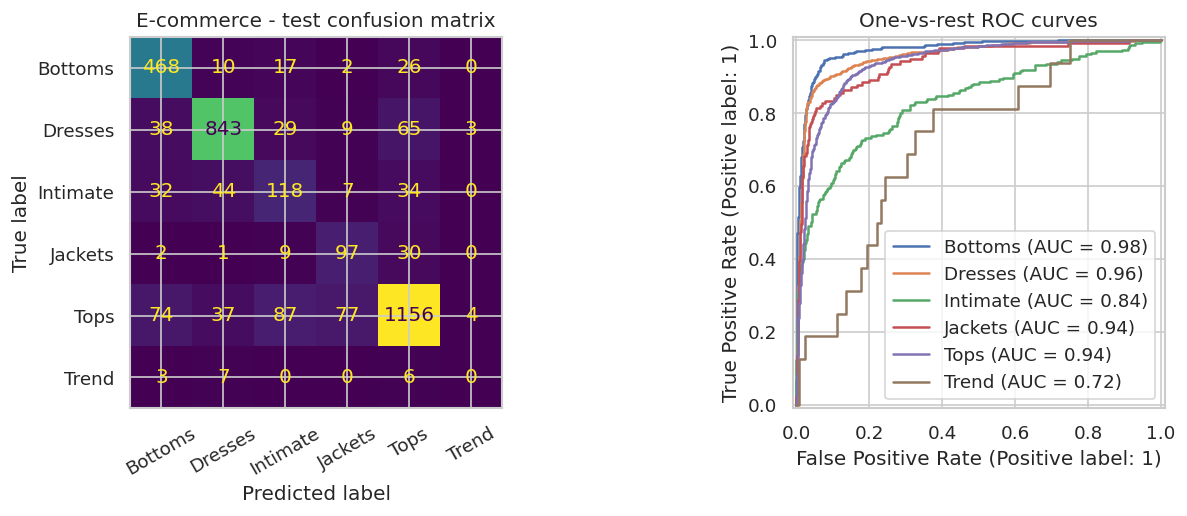

Confusion matrix rows=true, columns=predicted. Off-diagonal cells show confused interest categories.
Macro-F1 gives each category equal importance, including the rare Trend class; weighted-F1 is reported for context.
Saved models/ecommerce_pipeline.joblib and metadata.


In [9]:
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)
final_pipeline = Pipeline([("preprocess", clone(combined_preprocessor)), ("model", clone(models[selected_name]))])
final_pipeline.fit(X_trainval, y_trainval)
test_metrics = score_multiclass(final_pipeline, X_test, y_test)
print("FINAL TEST METRICS")
display(pd.DataFrame([test_metrics]).round(4))

test_pred = final_pipeline.predict(X_test)
cm = confusion_matrix(y_test, test_pred, labels=final_pipeline.classes_)
cm_frame = pd.DataFrame(cm, index=final_pipeline.classes_, columns=final_pipeline.classes_)
per_class = pd.DataFrame(classification_report(
    y_test, test_pred, labels=final_pipeline.classes_, output_dict=True, zero_division=0
)).T
display(cm_frame)
display(per_class.loc[final_pipeline.classes_, ["precision", "recall", "f1-score", "support"]].round(4))

off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
true_idx, pred_idx = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
print(
    "Largest confusion:", final_pipeline.classes_[true_idx], "->",
    final_pipeline.classes_[pred_idx], "=", int(off_diagonal[true_idx, pred_idx]), "reviews"
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[0], colorbar=False, xticks_rotation=30)
axes[0].set_title("E-commerce - test confusion matrix")
proba = final_pipeline.predict_proba(X_test)
classes = final_pipeline.classes_
y_bin = label_binarize(y_test, classes=classes)
for idx, cls in enumerate(classes):
    RocCurveDisplay.from_predictions(y_bin[:, idx], proba[:, idx], name=str(cls), ax=axes[1])
axes[1].set_title("One-vs-rest ROC curves")
plt.tight_layout()
plt.savefig(ROOT / "figures/ecommerce_test_evaluation.png", dpi=160, bbox_inches="tight")
plt.show()

print("Confusion matrix rows=true, columns=predicted. Off-diagonal cells show confused interest categories.")
print("Macro-F1 gives each category equal importance, including the rare Trend class; weighted-F1 is reported for context.")

joblib.dump(final_pipeline, ROOT / "models/ecommerce_pipeline.joblib", compress=3)
metadata = {
    "application": "ecommerce_interest_discovery",
    "dataset": "Women's E-Commerce Clothing Reviews",
    "dataset_url": "https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews",
    "selected_model": selected_name,
    "target": target,
    "classes": [str(item) for item in final_pipeline.classes_],
    "pipeline_features": features,
    "api_fields": ["title", "review_text", "age", "rating", "recommended_ind", "positive_feedback_count"],
    "excluded_leakage_features": ["Division Name", "Class Name"],
    "group_only_feature": "Clothing ID",
    "observations_original": int(len(df_raw)),
    "observations_clean": int(len(df)),
    "class_distribution_clean": {str(k): int(v) for k, v in df[target].value_counts().items()},
    "split_counts": {"train": int(len(X_train)), "validation": int(len(X_val)), "test": int(len(X_test))},
    "split": "approximately 70/15/15 with StratifiedGroupKFold grouped by Clothing ID after comment cleaning and de-duplication",
    "selection_metric": "macro F1",
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "test_confusion_matrix": cm.tolist(),
    "test_per_class": {
        str(label): {
            metric: float(per_class.loc[label, metric])
            for metric in ["precision", "recall", "f1-score", "support"]
        }
        for label in final_pipeline.classes_
    },
    "representation_ablation_validation": ablation_comparison.to_dict(orient="records"),
    "text_representation": {
        "model": "TF-IDF unigram/bigram fitted on train and concatenated with four scaled tabular features",
        "demonstration": "Comment -> tokens -> IDs -> SVD co-occurrence embeddings",
        "B": B,
        "T": T,
        "d": d_embed,
        "token_id_shape": list(input_ids.shape),
        "token_embedding_shape": list(token_embeddings.shape),
    },
    "final_input_shape": [
        int(len(X_trainval)),
        int(final_pipeline.named_steps["preprocess"].transform(X_trainval.head(1)).shape[1]),
    ],
    "random_state": RANDOM_STATE,
}
(ROOT / "models/ecommerce_metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Saved models/ecommerce_pipeline.joblib and metadata.")